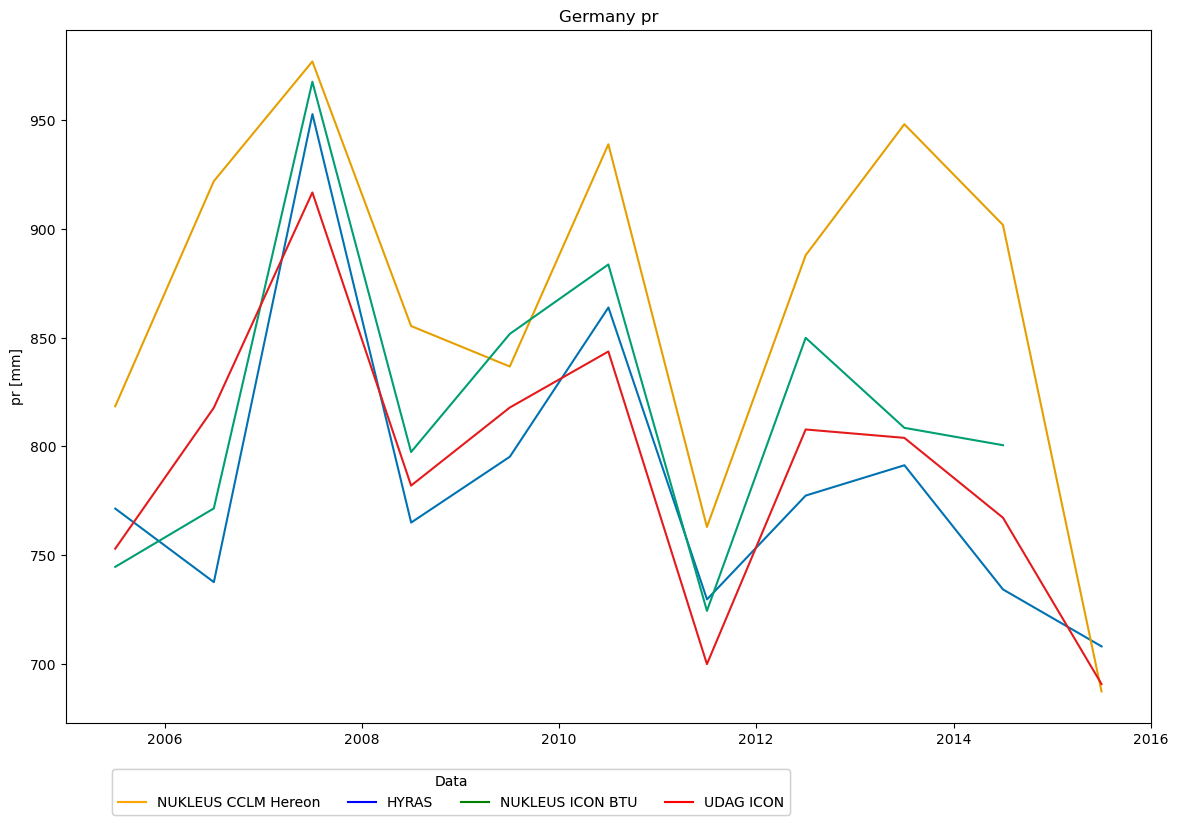

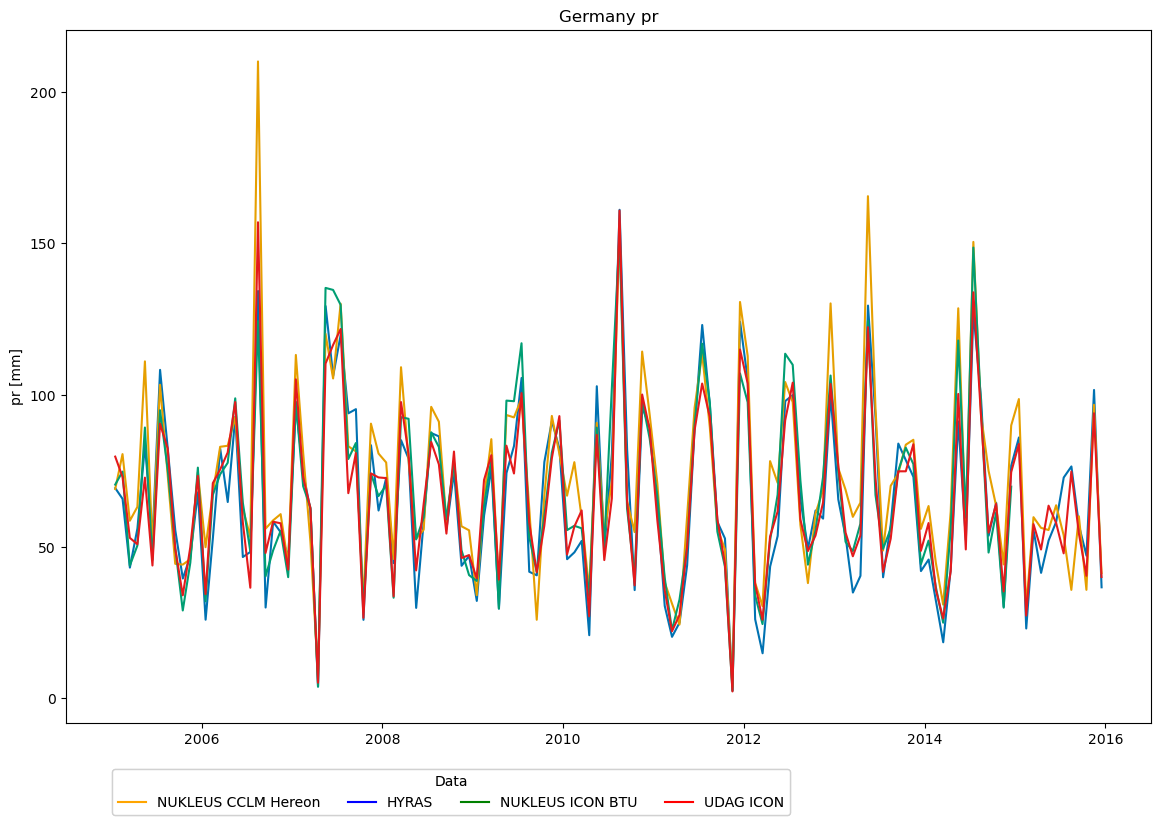

In [2]:
# Hyras original (original daily, now mean yearly):
# pr:long_name = "Daily Precipitation Sum" ;
# pr:cell_methods = "time: sum" ;
# pr:units = "mm" ;

# UDAG eval (hourly original, now mean yearly):
# pr:standard_name = "precipitation_amount" ;
# pr:long_name = "total precip" ;
# pr:units = "kg m-2" ;
# pr:grid_mapping = "rotated_pole" ;
# pr:coordinates = "lat lon" ;
# pr:_FillValue = -1.e+20f ;
# pr:missing_value = -1.e+20f ;
# pr:cell_methods = "time: sum" ;

# NUKLEUS data (monthly original, now mean yearly):
# pr:_FillValue = 1.e+20f ;
# pr:grid_mapping = "rotated_pole" ;
# pr:standard_name = "precipitation_flux" ;
# pr:long_name = "Precipitation" ;
# pr:units = "kg m-2 s-1" ;

import json

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def find_number_of_days_for_year(df):
    timeseries = []
    for year in df["time"].dt.year:
        timeseries.append(pd.Timestamp(year.item(), 12, 31).dayofyear)
    return timeseries


def plot_variable(ax, hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name):
    TOL_COLORS = {
        "blue": "#0072B2",
        "orange": "#E69F00",
        "green": "#009E73",
        "red": "#e41a1c",
    }

    ax.set_title(f"Germany {var_name}")
    with xr.open_dataset(hyras_path) as df:
        df = df.sel(time=slice("2005", "2015"))
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]),
            linestyle="solid",
            color=TOL_COLORS["blue"],
        )

    with xr.open_dataset(nukleus_hereon) as df:
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]),
            linestyle="solid",
            color=TOL_COLORS["orange"],
        )

    with xr.open_dataset(nukleus_btu) as df:
        df = df.sel(time=slice("2005", "2014"))
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]),
            linestyle="solid",
            color=TOL_COLORS["green"],
        )

    with xr.open_dataset(udag_eval) as df:
        df = df.sel(time=slice("2005", "2015"))
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]),
            linestyle="solid",
            color=TOL_COLORS["red"],
        )
    ax.set_ylabel("pr [mm]")


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "pr": load_json_file(f"{base_path}/NUKLEUS_Germany_pr_info.json"),
    },
    "HYRAS": {
        "pr": load_json_file(f"{base_path}/HYRAS_Germany_pr_info.json"),
    },
    "UDAG": {
        "pr": load_json_file(f"{base_path}/UDAG_Germany_pr_info.json"),
    },
}

for freq in ["yearly", "mon"]:
    fig, axes = plt.subplots(1, 1, figsize=(14, 9))  # , sharex=True, sharey=True)

    plot_variable(
        axes,
        files["HYRAS"]["pr"][freq],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["pr"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "pr",
    )

    scenario_color = {
        "NUKLEUS CCLM Hereon": "orange",
        "HYRAS": "blue",
        "NUKLEUS ICON BTU": "green",
        "UDAG ICON": "red",
    }
    handles = [
        mlines.Line2D([], [], color=scenario_color[s], linestyle="solid", label=s)
        for s in scenario_color
    ]

    legend = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.4, -0.00),
        ncol=len(handles),
        title="Data",
    )
    fig.add_artist(legend)
    plt.savefig(
        f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/EVAL_HYRAS_pr_{freq}.png",
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()


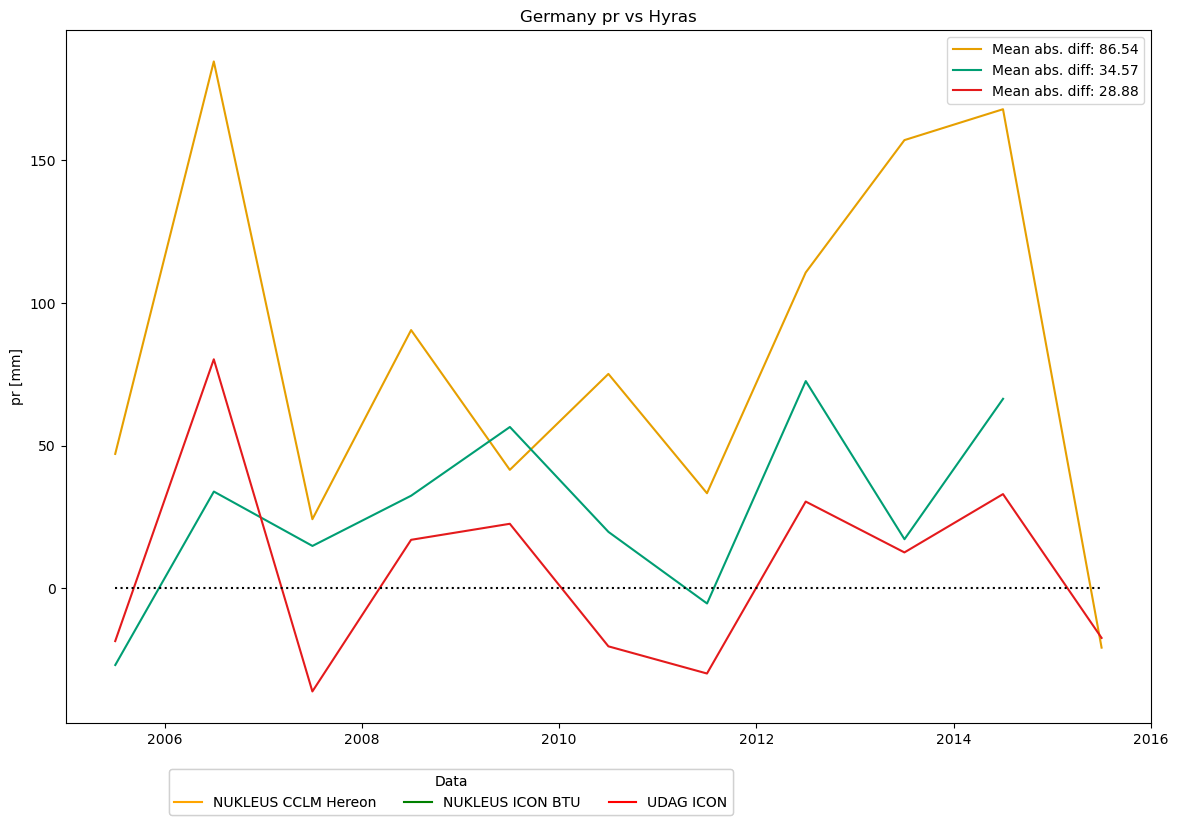

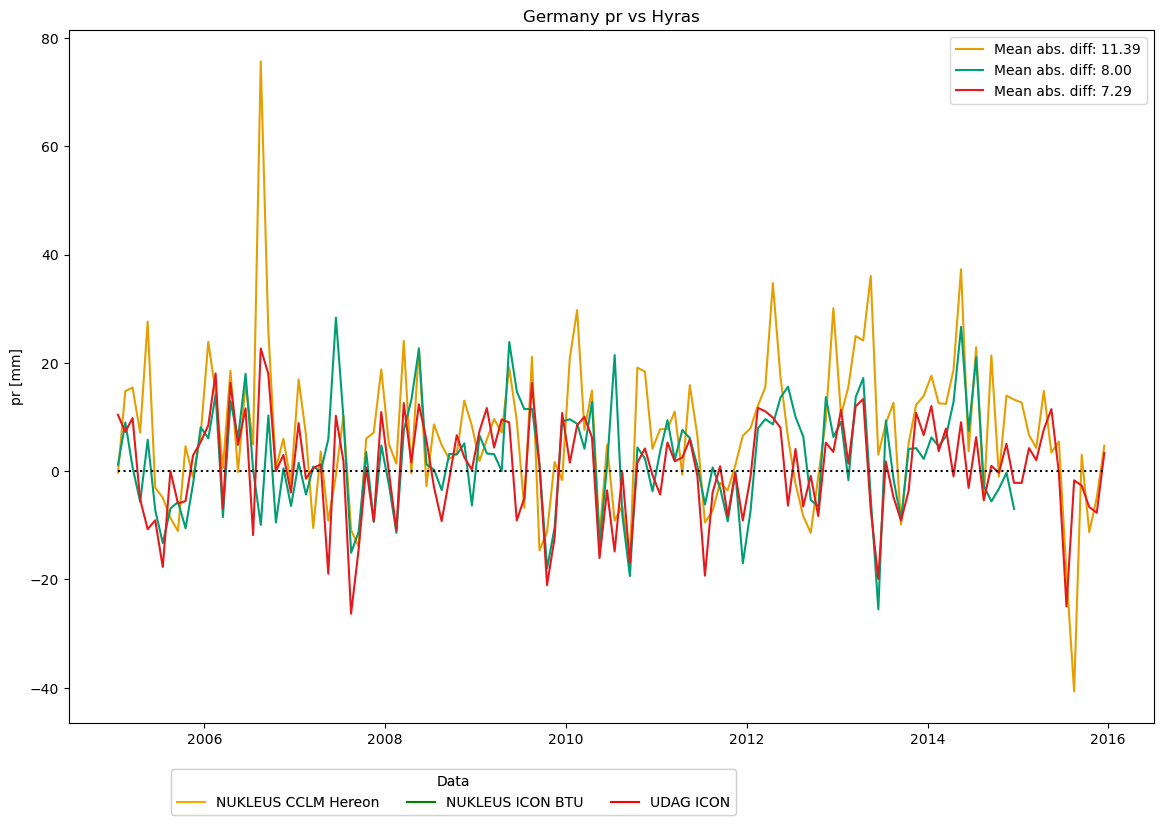

In [3]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def plot_variable(ax, hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name):
    TOL_COLORS = {
        "blue": "#0072B2",
        "orange": "#E69F00",
        "green": "#009E73",
        "red": "#e41a1c",
    }

    ax.set_title(f"Germany {var_name} vs Hyras")
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2015"))
        with xr.open_dataset(nukleus_hereon) as df:
            diff = (np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values),)
            ax.plot(
                np.squeeze(df["time"]),
                np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values),
                linestyle="solid",
                color=TOL_COLORS["orange"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
        with xr.open_dataset(nukleus_btu) as df:
            diff = (
                np.squeeze(df[var_name].values)
                - np.squeeze(
                    dx[var_name].values[0 : len(np.squeeze(df[var_name].values))]
                ),
            )
            ax.plot(
                np.squeeze(dx["time"][0 : len(np.squeeze(df[var_name].values))]),
                np.squeeze(df[var_name].values)
                - np.squeeze(
                    dx[var_name].values[0 : len(np.squeeze(df[var_name].values))]
                ),
                linestyle="solid",
                color=TOL_COLORS["green"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2015"))
            diff = np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values)
            ax.plot(
                np.squeeze(df["time"]),
                diff,
                linestyle="solid",
                color=TOL_COLORS["red"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
            ax.plot(df["time"], [0] * len(df["time"]), linestyle=":", color="black")
    ax.set_ylabel("pr [mm]")
    ax.legend()


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "pr": load_json_file(f"{base_path}/NUKLEUS_Germany_pr_info.json"),
    },
    "HYRAS": {
        "pr": load_json_file(f"{base_path}/HYRAS_Germany_pr_info.json"),
    },
    "UDAG": {
        "pr": load_json_file(f"{base_path}/UDAG_Germany_pr_info.json"),
    },
}

for freq in ["yearly", "mon"]:
    fig, axes = plt.subplots(1, 1, figsize=(14, 9))  # , sharex=True, sharey=True)

    plot_variable(
        axes,
        files["HYRAS"]["pr"][freq],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["pr"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "pr",
    )

    scenario_color = {
        "NUKLEUS CCLM Hereon": "orange",
        "NUKLEUS ICON BTU": "green",
        "UDAG ICON": "red",
    }
    handles = [
        mlines.Line2D([], [], color=scenario_color[s], linestyle="solid", label=s)
        for s in scenario_color
    ]

    legend = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.4, -0.00),
        ncol=len(handles),
        title="Data",
    )
    fig.add_artist(legend)
    plt.savefig(
        f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/Diff_EVAL_HYRAS_pr_{freq}.png",
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()


In [4]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def mean_abs_diff(hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name, freq):
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2014"))
        with xr.open_dataset(nukleus_hereon) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values),)
            print(
                f"Mean abs. diff Nukleus Hereon {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(nukleus_btu) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values),)
            print(
                f"Mean abs. diff Nukleus BTU {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = np.squeeze(df[list(df.keys())[1]].values) - np.squeeze(
                dx[var_name].values
            )
            print(f"Mean abs. diff UDAG {variable} {freq}: {np.mean(np.abs(diff)):.2f}")


def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w


def three_day_mean_abs_diff(
    hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name, freq
):
    freq = "3 day mean"
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2014"))
        with xr.open_dataset(nukleus_hereon) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                moving_average(np.squeeze(df[var_name].values), 3)
                - moving_average(np.squeeze(dx[var_name].values), 3),
            )
            print(
                f"Moving mean abs. diff Nukleus Hereon {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(nukleus_btu) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                moving_average(np.squeeze(df[var_name].values), 3)
                - moving_average(np.squeeze(dx[var_name].values), 3),
            )
            print(
                f"Moving mean abs. diff Nukleus BTU {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = moving_average(
                np.squeeze(df[list(df.keys())[1]].values), 3
            ) - moving_average(np.squeeze(dx[var_name].values), 3)
            print(
                f"Moving mean abs. diff UDAG {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "pr": load_json_file(f"{base_path}/NUKLEUS_Germany_pr_info.json"),
    },
    "HYRAS": {
        "pr": load_json_file(f"{base_path}/HYRAS_Germany_pr_info.json"),
    },
    "UDAG": {
        "pr": load_json_file(f"{base_path}/UDAG_Germany_pr_info.json"),
    },
}

for variable in ["pr"]:
    for freq in ["yearly", "mon", "day"]:
        mean_abs_diff(
            files["HYRAS"][variable][freq],
            files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][1],
            files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][0],
            files["UDAG"][variable][freq]["ERA5"]["evaluation"]["MEU-3"][0],
            variable,
            freq,
        )

    three_day_mean_abs_diff(
        files["HYRAS"][variable][freq],
        files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"][variable][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        variable,
        "day",
    )

Mean abs. diff Nukleus Hereon pr yearly: 93.12
Mean abs. diff Nukleus BTU pr yearly: 34.57
Mean abs. diff UDAG pr yearly: 30.04
Mean abs. diff Nukleus Hereon pr mon: 11.44
Mean abs. diff Nukleus BTU pr mon: 8.00
Mean abs. diff UDAG pr mon: 7.39
Mean abs. diff Nukleus Hereon pr day: 1.15
Mean abs. diff Nukleus BTU pr day: 0.99
Mean abs. diff UDAG pr day: 0.98
Moving mean abs. diff Nukleus Hereon pr 3 day mean: 0.79
Moving mean abs. diff Nukleus BTU pr 3 day mean: 0.63
Moving mean abs. diff UDAG pr 3 day mean: 0.63


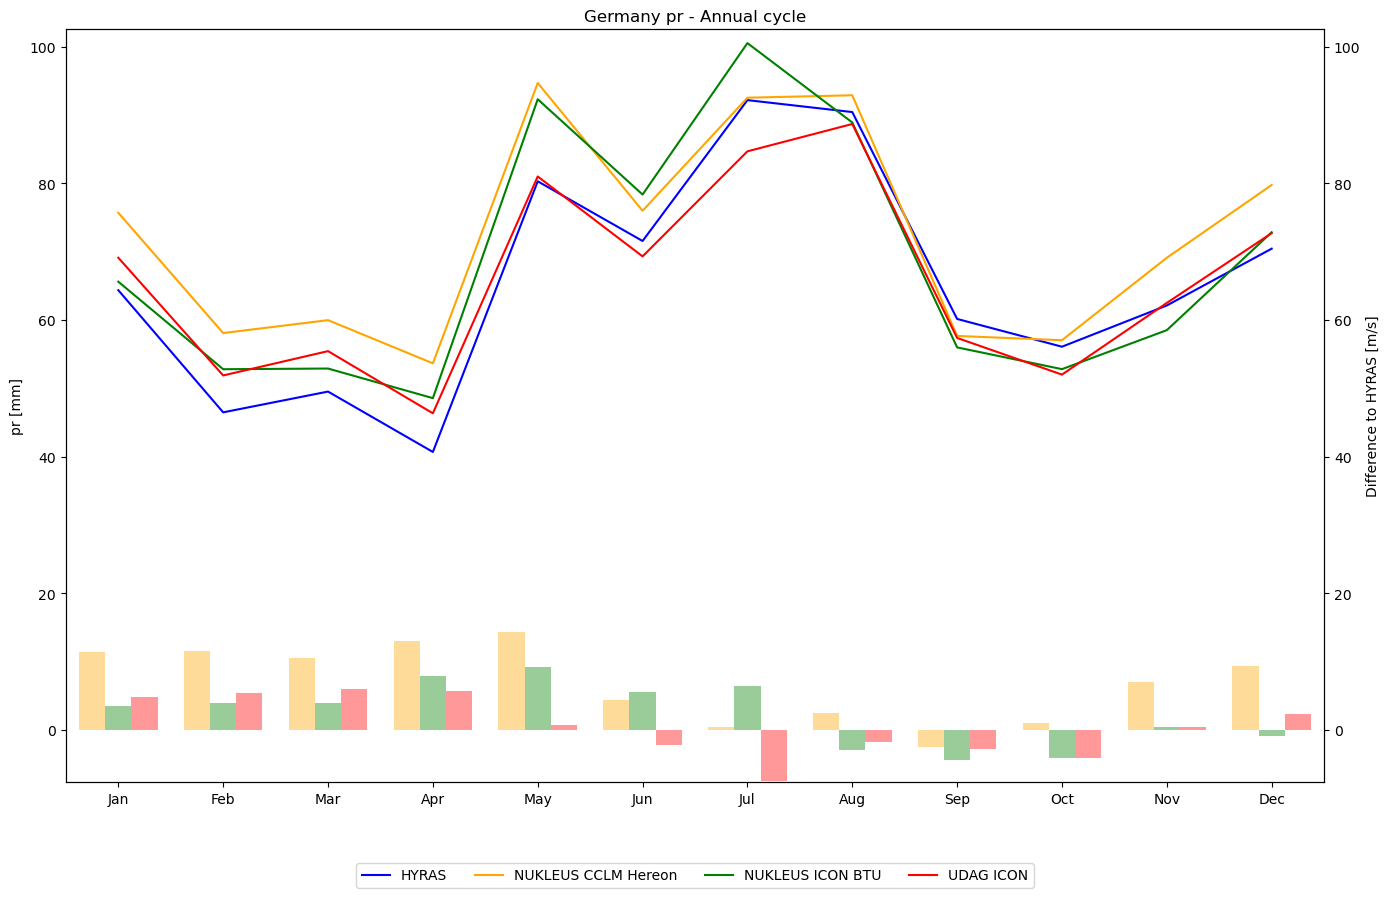

In [ ]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def monthly_mean(ds, var):
    return ds[var].groupby("time.month").mean()


# ---------------------------------------------------------
# File loading
# ---------------------------------------------------------

base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"
var_name = "pr"
files = {
    "NUKLEUS": {
        var_name: load_json_file(f"{base_path}/NUKLEUS_Germany_{var_name}_info.json"),
    },
    "HYRAS": {
        var_name: load_json_file(f"{base_path}/HYRAS_Germany_{var_name}_info.json"),
    },
    "UDAG": {
        var_name: load_json_file(f"{base_path}/UDAG_Germany_{var_name}_info.json"),
    },
}

freq = "mon"

# ---------------------------------------------------------
# Dataset definitions
# ---------------------------------------------------------

datasets = {
    "NUKLEUS CCLM Hereon": files["NUKLEUS"][var_name][freq]["ERA5"]["evaluation"][
        "CEU-3"
    ][1],
    "NUKLEUS ICON BTU": files["NUKLEUS"][var_name][freq]["ERA5"]["evaluation"]["CEU-3"][
        0
    ],
    "UDAG ICON": files["UDAG"][var_name][freq]["ERA5"]["evaluation"]["MEU-3"][0],
}

colors = {
    "HYRAS": "blue",
    "NUKLEUS CCLM Hereon": "orange",
    "NUKLEUS ICON BTU": "green",
    "UDAG ICON": "red",
}

# ---------------------------------------------------------
# Time windows per dataset
# ---------------------------------------------------------

time_windows = {
    "NUKLEUS CCLM Hereon": ("2005", "2015"),
    "NUKLEUS ICON BTU": ("2005", "2014"),  # special case
    "UDAG ICON": ("2005", "2015"),
}

# ---------------------------------------------------------
# Load HYRAS full (2005–2015) for plotting the HYRAS curve
# ---------------------------------------------------------

with xr.open_dataset(files["HYRAS"][var_name][freq]) as ds_hyras_full:
    ds_hyras_full = ds_hyras_full.sel(time=slice("2005", "2015"))
    hyras_monthly_full = monthly_mean(ds_hyras_full, var_name)

# ---------------------------------------------------------
# Load all model datasets and compute monthly means + differences
# ---------------------------------------------------------

monthly_means = {}
monthly_diffs = {}

for name, path in datasets.items():
    start, end = time_windows[name]

    # Load model dataset with its own time window
    with xr.open_dataset(path) as ds:
        ds = ds.sel(time=slice(start, end))
        monthly_means[name] = monthly_mean(ds, var_name)

    # Load matching HYRAS window for this dataset
    with xr.open_dataset(files["HYRAS"][var_name][freq]) as ds_hyras_local:
        ds_hyras_local = ds_hyras_local.sel(time=slice(start, end))
        hyras_monthly_local = monthly_mean(ds_hyras_local, var_name)

    # Compute difference (model - HYRAS) for the matching window
    diff = xr.DataArray(
        monthly_means[name].values - hyras_monthly_local.values,
        dims=hyras_monthly_local.dims,
        coords=hyras_monthly_local.coords,
    )
    monthly_diffs[name] = diff

# ---------------------------------------------------------
# Compute global min/max across all curves and bars
# ---------------------------------------------------------

all_monthly = [hyras_monthly_full] + list(monthly_means.values())
all_diffs = list(monthly_diffs.values())

min_value = xr.concat(all_monthly + all_diffs, dim="source").min().item()
max_value = xr.concat(all_monthly + all_diffs, dim="source").max().item()

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 9))
months = np.arange(1, 13)

# HYRAS curve (always 2005–2015)
ax.plot(months, hyras_monthly_full, color=colors["HYRAS"], label="HYRAS")

# Model curves
for name, monthly in monthly_means.items():
    ax.plot(months, monthly, color=colors[name], label=name)

ax.set_ylabel("pr [mm]")
ax.set_title("Germany pr - Annual cycle")
ax.set_ylim(min_value * 1.02, max_value * 1.02)

# Side-by-side bars for differences
ax2 = ax.twinx()
bw = 0.25  # bar width

for i, (name, diff) in enumerate(monthly_diffs.items()):
    offset = (i - 1) * bw
    ax2.bar(months + offset, diff.values, width=bw, alpha=0.4, color=colors[name])

ax2.set_ylim(min_value * 1.02, max_value * 1.02)
ax2.set_ylabel("Difference to HYRAS [mm]")

# Legend
handles = [mlines.Line2D([], [], color=colors[k], label=k) for k in colors]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=4)

# Month labels
month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlim(0.5, 12.5)

plt.tight_layout()
plt.savefig(
    f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/EVAL_HYRAS_{var_name}_AC_{freq}.png",
    bbox_inches="tight",
    format="png",
    dpi=300,
)
plt.show()
